# 01. Game design

This is the first of five notebooks for our 6x6 tic-tac-toe variant. The
goal of this one is to set up the game itself: the rules, the data
structures, the random pre-allocation that makes the variant interesting,
and a few sanity checks on win detection. Nothing here is doing any AI
yet, that starts in notebook 02.

The game is built on top of AIMA's `games4e.TicTacToe` so we get
`actions`, `result`, `utility`, and `terminal_test` for free, and we
override only what changes for the variant. Configuration (board size,
win length, RNG seed, etc.) lives in `settings.py` and is shared by
every notebook in the project.


In [1]:
import os, sys, random
# Make sure the project root is on sys.path so we can import settings/tictactoe66
_here = os.path.abspath(os.path.join(os.getcwd(), '..'))
if _here not in sys.path:
    sys.path.insert(0, _here)

import settings
import tictactoe66
from games4e import GameState

print('Board size :', settings.BOARD_SIZE, 'x', settings.BOARD_SIZE)
print('Win length :', settings.WIN_LENGTH)
print('Pre-alloc choices :', settings.PREALLOC_CHOICES)

Board size : 6 x 6
Win length : 4
Pre-alloc choices : (1, 2, 3)


## The game class

`TicTacToe66` subclasses `games4e.TicTacToe` with `h=v=6` and `k=4`. We
override `display` to get a board that's pleasant to read, and add a
cached `lines()` helper that the heuristic in notebook 02 uses to walk
every length-4 window once instead of recomputing them per evaluation.


In [2]:
game = tictactoe66.TicTacToe66()
print('All length-4 windows on the board:', len(game.lines()))
game.display(game.initial)

All length-4 windows on the board: 54
     1  2  3  4  5  6
   +------------------+
 1 |  .  .  .  .  .  . |
 2 |  .  .  .  .  .  . |
 3 |  .  .  .  .  .  . |
 4 |  .  .  .  .  .  . |
 5 |  .  .  .  .  .  . |
 6 |  .  .  .  .  .  . |
   +------------------+


## Random initial state

`make_initial_state(game, n_prealloc, rng)` drops `n_prealloc` X's and
`n_prealloc` O's at random into distinct empty cells before play starts,
with X to move first. This is the bit that makes the variant
non-deterministic: the same agents on the same board can play very
different games depending on what the RNG hands them.


In [3]:
rng = random.Random(settings.RANDOM_SEED)
for n in settings.PREALLOC_CHOICES:
    print(f'\n--- n_prealloc = {n} ---')
    s = tictactoe66.make_initial_state(game, n, rng=rng)
    game.display(s)
    print('to_move:', s.to_move, 'remaining moves:', len(s.moves))


--- n_prealloc = 1 ---
     1  2  3  4  5  6
   +------------------+
 1 |  .  O  .  .  .  . |
 2 |  .  X  .  .  .  . |
 3 |  .  .  .  .  .  . |
 4 |  .  .  .  .  .  . |
 5 |  .  .  .  .  .  . |
 6 |  .  .  .  .  .  . |
   +------------------+
to_move: X remaining moves: 34

--- n_prealloc = 2 ---
     1  2  3  4  5  6
   +------------------+
 1 |  .  .  .  .  .  . |
 2 |  .  .  O  .  .  . |
 3 |  .  .  O  X  .  X |
 4 |  .  .  .  .  .  . |
 5 |  .  .  .  .  .  . |
 6 |  .  .  .  .  .  . |
   +------------------+
to_move: X remaining moves: 32

--- n_prealloc = 3 ---
     1  2  3  4  5  6
   +------------------+
 1 |  O  .  O  .  .  X |
 2 |  X  .  .  .  .  . |
 3 |  .  .  .  .  .  . |
 4 |  .  .  .  .  .  . |
 5 |  .  .  .  O  .  . |
 6 |  .  .  .  .  X  . |
   +------------------+
to_move: X remaining moves: 30


## Win detection

The base class's `compute_utility` already handles `k`-in-a-row in any
direction, so all we really need is a quick sanity check that rows,
columns, and both diagonals trigger correctly. The cell below sets up
one of each and confirms the utility flips and the terminal test fires.


In [4]:
def make_state(board, to_move='X'):
    moves = [(x, y) for x in range(1, game.h+1) for y in range(1, game.v+1) if (x, y) not in board]
    util = tictactoe66._scan_utility(game, board)
    return GameState(to_move=to_move, utility=util, board=board, moves=moves)

tests = {
    'row':       {(3, j): 'X' for j in (1,2,3,4)},
    'col':       {(i, 4): 'O' for i in (2,3,4,5)},
    'diag-down': {(i, i): 'X' for i in (1,2,3,4)},
    'diag-up':   {(5-i, 1+i): 'O' for i in (0,1,2,3)},
}
for name, b in tests.items():
    s = make_state(b)
    print(f'{name:10s}  utility={s.utility:+d}  terminal={game.terminal_test(s)}')

row         utility=+1  terminal=True
col         utility=-1  terminal=True
diag-down   utility=+1  terminal=True
diag-up     utility=-1  terminal=True


## Human-vs-human loop

A manual game loop is useful for spot-checking that the rules behave as
expected end-to-end. Enter moves as `row,col` (1-indexed); type `quit`
to abort.

It's disabled by default because `input()` blocks "Run All". Flip
`RUN_INTERACTIVE = True` if you want to play.


In [5]:
RUN_INTERACTIVE = False

def human_player(game, state):
    while True:
        raw = input(f"{state.to_move} move (row,col): ").strip()
        if raw.lower() in ('q', 'quit'):
            raise SystemExit('aborted by user')
        try:
            r, c = (int(t) for t in raw.replace(' ', '').split(','))
        except ValueError:
            print('  bad input, try again, e.g. 3,4')
            continue
        if (r, c) in state.moves:
            return (r, c)
        print('  illegal, must be one of the empty cells')

if RUN_INTERACTIVE:
    # Interactive human-vs-human game.  Type "q" or "quit" at any prompt to abort.
    res = tictactoe66.play_one_game(game, human_player, human_player,
                               n_prealloc=2, rng=random.Random(0), display=True)
    print('result:', res)
else:
    print('Human-vs-human loop disabled (set RUN_INTERACTIVE = True to enable).')

Human-vs-human loop disabled (set RUN_INTERACTIVE = True to enable).


## Cell coverage

Not every cell on the board is equally useful. Corners sit on a handful
of length-4 windows; central cells sit on many more. That asymmetry is
the geometric reason the heuristic in notebook 02 has a `w_center`
term, and the heatmap below makes it concrete.


saved C:\Git\AI801Project\cache\figures\cell_coverage.png


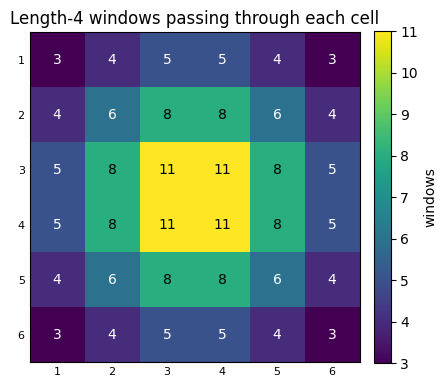

In [6]:
import matplotlib.pyplot as plt
import viz

fig, ax = plt.subplots(figsize=(4.5, 4.5))
im = viz.draw_cell_coverage(ax, game)
ax.set_title('Length-4 windows passing through each cell')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='windows')
fig.tight_layout()
out = settings.FIGURES_DIR / 'cell_coverage.png'
fig.savefig(out, dpi=120)
print('saved', out)
plt.show()


That's the game itself. Notebook 02 layers alpha-beta and the
heuristic on top.
